# Ethical Analysis

Clean fairness analysis for the Stage 2 behavioral clusters. The reference clustering is `spectral_eucl`, renamed here as `cluster_spectral_eucl` to keep the method explicit. The analysis is exploratory: Stage 2 uses a stratified trajectory subsample, and several users can appear in multiple trajectory windows.

## 1. Setup and Data Loading

Load Stage 1 demographics, Stage 2 cluster assignments, and merge them into one analysis table.

In [1]:
import os
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
try:
    from scipy.stats import chi2_contingency
except ImportError:
    chi2_contingency = None

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 150)
pd.set_option("display.width", 250)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid", palette="Set2")

DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

REFERENCE_CLUSTER_SOURCE = "spectral_eucl"
CLUSTER_COL = "cluster_spectral_eucl"
OUTCOME_COL = "stage2_outcome"
MIN_GROUP_SIZE = 30
DISPARITY_LOW = 0.8
DISPARITY_HIGH = 1.25
ROBUSTNESS_CLUSTER_COLS = ["kmeans_eucl", "kmeans_flat"]

In [2]:
df_stage1 = pd.read_csv(DATA_DIR / "stage1.csv.gz")
stage2_clusters = pd.read_csv(OUTPUT_DIR / "stage2_spectral_assignments.csv")

print(f"Stage 1 rows: {len(df_stage1):,}")
print(f"Stage 2 cluster rows: {len(stage2_clusters):,}")
print("Stage 2 columns:", stage2_clusters.columns.tolist())

Stage 1 rows: 22,466
Stage 2 cluster rows: 7,500
Stage 2 columns: ['user_id', 'end_week', 'is_dropout_point', 'spectral_agg', 'spectral_eucl', 'kmeans_flat', 'kmeans_eucl']


## 2. Build the Analysis Table

Extract demographic fields from one-hot columns, add education/school categories, then merge the Stage 2 labels.

In [3]:
def one_hot_label(df, prefix, default="Unknown"):
    cols = [c for c in df.columns if c.startswith(prefix)]
    if not cols:
        return pd.Series(default, index=df.index)
    labels = df[cols].idxmax(axis=1).str.replace(prefix, "", regex=False)
    empty_rows = df[cols].sum(axis=1) == 0
    return labels.mask(empty_rows, default)


def extract_demographics(df):
    demo = df[["user_id"]].copy()
    demo["gender"] = one_hot_label(df, "gender_")
    demo["canton"] = one_hot_label(df, "canton_")
    demo["school"] = one_hot_label(df, "school_")

    for col in ["study", "class_year", "came_back"]:
        if col in df.columns:
            demo[col] = df[col]

    if "came_back" in demo.columns:
        demo = demo.rename(columns={"came_back": "continuation_indicator"})

    return demo


def categorize_education_level(row):
    school = str(row.get("school", "")).lower()

    if any(x in school for x in ["1. klasse", "2. klasse", "3. klasse", "4. klasse", "5. klasse", "6. klasse", "7. klasse", "primaire"]):
        return "Primary_LowerSec"
    if any(x in school for x in ["gymnasium", "lycee", "liceo", "matura", "maturitat", "hms", "ims", "isme", "passerelle"]):
        return "Secondary"
    if any(x in school for x in ["bme", "fm", "fms", "fachmatur", "apprentice"]):
        return "Tertiary_Apprentice"
    return "Unknown"


def categorize_school_type(school):
    school = str(school).lower()
    if any(x in school for x in ["gymnasium", "lycee", "liceo", "matura", "maturitat", "passerelle"]):
        return "Academic"
    if any(x in school for x in ["bme", "fm", "fms", "fachmatur", "apprentice"]):
        return "Vocational"
    if any(x in school for x in ["sekundar", "realschule", "klasse"]):
        return "Secondary"
    if school in ["unknown", "keine angabe"]:
        return "Unknown"
    return "Other"


demographics = extract_demographics(df_stage1)
demographics["education_level"] = demographics.apply(categorize_education_level, axis=1)
demographics["school_type"] = demographics["school"].apply(categorize_school_type)

cluster_cols = [
    "user_id",
    "end_week",
    "is_dropout_point",
    "spectral_eucl",
    "spectral_agg",
    "kmeans_flat",
    "kmeans_eucl",
]
stage2 = stage2_clusters[cluster_cols].copy()
stage2 = stage2.rename(columns={REFERENCE_CLUSTER_SOURCE: CLUSTER_COL})
stage2[OUTCOME_COL] = pd.to_numeric(stage2["is_dropout_point"], errors="coerce")

analysis_df = demographics.merge(stage2, on="user_id", how="inner")
analysis_df[CLUSTER_COL] = analysis_df[CLUSTER_COL].astype("category")

print(f"Rows kept after Stage 2 merge: {len(analysis_df):,} / {len(demographics):,}")
print(f"Unique users kept after Stage 2 merge: {analysis_df['user_id'].nunique():,} / {demographics['user_id'].nunique():,}")
print("Outcome distribution:")
print(analysis_df[OUTCOME_COL].value_counts(dropna=False).sort_index())
print("\nReference cluster distribution:")
print(analysis_df[CLUSTER_COL].value_counts().sort_index())

Rows kept after Stage 2 merge: 7,498 / 22,466
Unique users kept after Stage 2 merge: 4,375 / 22,466
Outcome distribution:
stage2_outcome
0    3772
1    3726
Name: count, dtype: int64

Reference cluster distribution:
cluster_spectral_eucl
0    4470
1     954
2     607
3    1467
Name: count, dtype: int64


## 3. Subsample Coverage and Representativeness

The spectral clustering assignments come from a stratified Stage 2 trajectory subsample, not from all Stage 1 users. Users can appear in multiple Stage 2 windows, so the notebook reports both trajectory-window counts and unique-user counts. Downstream fairness results should therefore be read as exploratory fairness diagnostics on the clustered Stage 2 subsample.

In [4]:
sample_user_ids = set(analysis_df["user_id"].unique())
full_user_ids = set(demographics["user_id"].unique())

coverage_summary = pd.DataFrame({
    "metric": [
        "Stage 1 demographic rows",
        "Stage 1 unique users",
        "Stage 2 clustered trajectory rows",
        "Stage 2 clustered unique users",
        "Unique-user coverage rate",
        "Mean trajectory rows per clustered user",
    ],
    "value": [
        len(demographics),
        demographics["user_id"].nunique(),
        len(analysis_df),
        analysis_df["user_id"].nunique(),
        analysis_df["user_id"].nunique() / demographics["user_id"].nunique(),
        len(analysis_df) / analysis_df["user_id"].nunique(),
    ],
})

coverage_summary

,metric,value
0,Stage 1 demographic rows,22466.000000
1,Stage 1 unique users,22466.000000
2,Stage 2 clustered trajectory rows,7498.000000
3,Stage 2 clustered unique users,4375.000000
4,Unique-user coverage rate,0.194739
5,Mean trajectory rows per clustered user,1.713829


In [5]:
def compare_sample_distribution(full_df, sample_df, col):
    full_pct = full_df[col].value_counts(normalize=True).rename("full_stage1_pct")
    sample_pct = sample_df[col].value_counts(normalize=True).rename("clustered_subsample_pct")
    comp = pd.concat([full_pct, sample_pct], axis=1).fillna(0) * 100
    comp["percentage_point_gap"] = comp["clustered_subsample_pct"] - comp["full_stage1_pct"]
    return comp.sort_values("percentage_point_gap", key=lambda s: s.abs(), ascending=False)

sample_checks = {
    "gender": compare_sample_distribution(demographics, analysis_df.drop_duplicates("user_id"), "gender"),
    "education_level": compare_sample_distribution(demographics, analysis_df.drop_duplicates("user_id"), "education_level"),
    "school_type": compare_sample_distribution(demographics, analysis_df.drop_duplicates("user_id"), "school_type"),
}

for attr, table in sample_checks.items():
    print(f"\n=== Subsample representativeness: {attr} ===")
    display(table.round(2))



=== Subsample representativeness: gender ===


,full_stage1_pct,clustered_subsample_pct,percentage_point_gap
gender,,,
Unknown,6.54,9.97,3.42
MALE,35.92,33.21,-2.71
FEMALE,53.89,53.01,-0.88
Other,3.65,3.82,0.17



=== Subsample representativeness: education_level ===


,full_stage1_pct,clustered_subsample_pct,percentage_point_gap
education_level,,,
Tertiary_Apprentice,11.40,9.14,-2.26
Unknown,12.89,14.42,1.54
Secondary,74.70,75.70,1.00
Primary_LowerSec,1.01,0.73,-0.28



=== Subsample representativeness: school_type ===


,full_stage1_pct,clustered_subsample_pct,percentage_point_gap
school_type,,,
Unknown,7.50,10.83,3.33
Vocational,11.40,9.14,-2.26
Other,6.83,4.89,-1.94
Academic,73.23,74.40,1.17
Secondary,1.03,0.73,-0.30


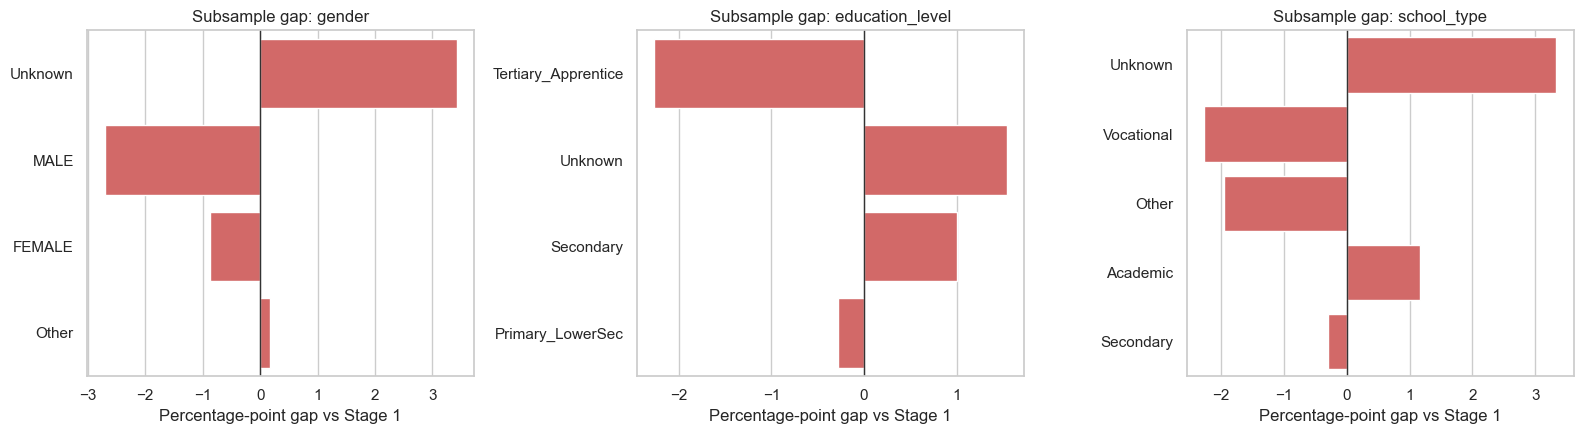

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (attr, table) in zip(axes, sample_checks.items()):
    plot_table = table.reset_index().rename(columns={"index": attr})
    sns.barplot(data=plot_table, y=attr, x="percentage_point_gap", ax=ax, color="#E45756")
    ax.axvline(0, color="#333333", linewidth=1)
    ax.set_title(f"Subsample gap: {attr}")
    ax.set_xlabel("Percentage-point gap vs Stage 1")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()


## 4. Cluster Overview

First check whether the reference clusters have comparable sizes and different dropout-point rates. `n_rows` counts trajectory windows, while `n_unique_users` counts distinct learners.

In [7]:
cluster_summary = (
    analysis_df.groupby(CLUSTER_COL, observed=False)
    .agg(
        n_rows=("user_id", "size"),
        n_unique_users=("user_id", "nunique"),
        dropout_point_rate=(OUTCOME_COL, "mean"),
        non_dropout_point_rate=(OUTCOME_COL, lambda x: 1 - x.mean()),
    )
    .sort_index()
)
cluster_summary["rows_per_user"] = cluster_summary["n_rows"] / cluster_summary["n_unique_users"]

cluster_summary

,n_rows,n_unique_users,dropout_point_rate,non_dropout_point_rate,rows_per_user
cluster_spectral_eucl,,,,,
0,4470,2981,0.536018,0.463982,1.499497
1,954,841,0.443396,0.556604,1.134364
2,607,589,0.485997,0.514003,1.030560
3,1467,1197,0.417178,0.582822,1.225564


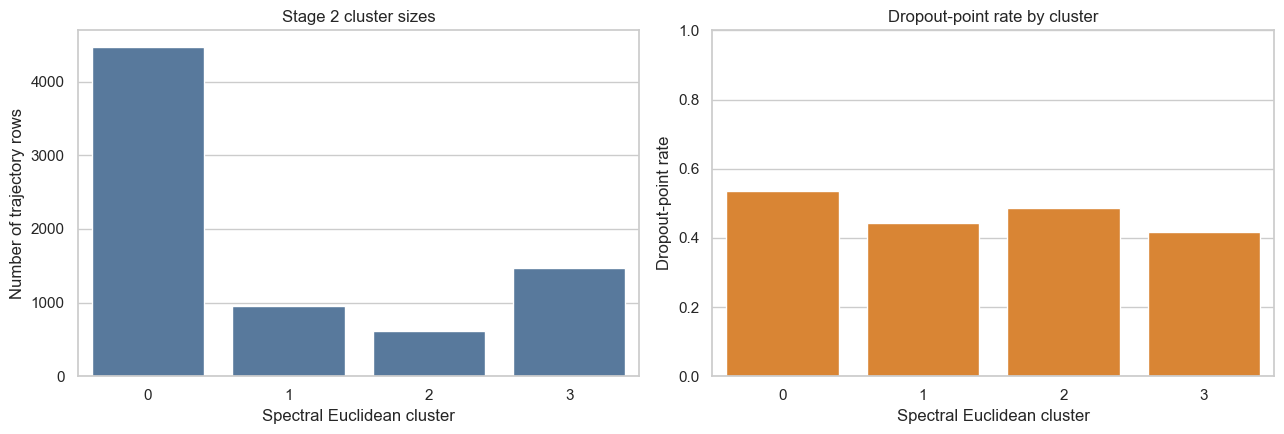

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.barplot(
    data=cluster_summary.reset_index(),
    x=CLUSTER_COL,
    y="n_rows",
    ax=axes[0],
    color="#4C78A8",
)
axes[0].set_title("Stage 2 cluster sizes")
axes[0].set_xlabel("Spectral Euclidean cluster")
axes[0].set_ylabel("Number of trajectory rows")

sns.barplot(
    data=cluster_summary.reset_index(),
    x=CLUSTER_COL,
    y="dropout_point_rate",
    ax=axes[1],
    color="#F58518",
)
axes[1].set_title("Dropout-point rate by cluster")
axes[1].set_xlabel("Spectral Euclidean cluster")
axes[1].set_ylabel("Dropout-point rate")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 5. Representation Fairness

Check whether each demographic group is similarly represented across clusters. Strong differences may mean the clustering captures demographic structure.

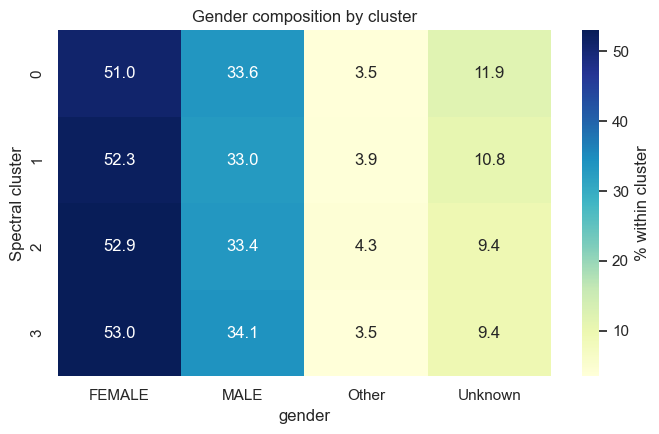

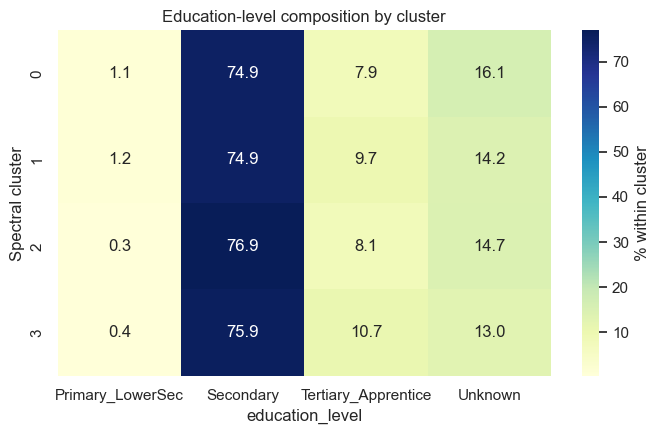

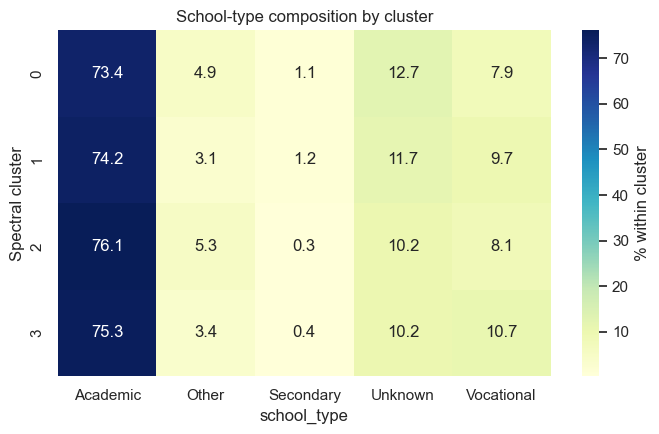

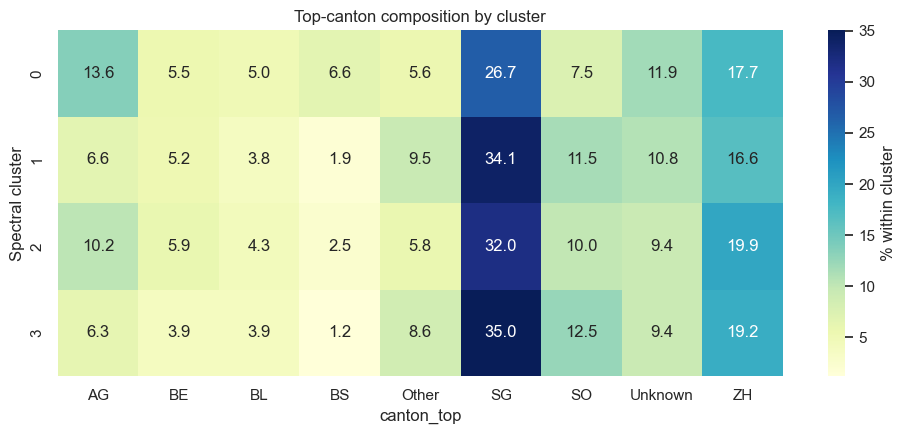

In [9]:
def composition_table(df, group_col, cluster_col=CLUSTER_COL):
    counts = pd.crosstab(df[cluster_col], df[group_col])
    pct = pd.crosstab(df[cluster_col], df[group_col], normalize="index") * 100
    return counts, pct


def plot_composition_heatmap(df, group_col, title, cluster_col=CLUSTER_COL):
    _, pct = composition_table(df, group_col, cluster_col)
    plt.figure(figsize=(max(7, 1.1 * len(pct.columns)), 4.5))
    sns.heatmap(pct, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={"label": "% within cluster"})
    plt.title(title)
    plt.xlabel(group_col)
    plt.ylabel("Spectral cluster")
    plt.tight_layout()
    plt.show()
    return pct


gender_comp = plot_composition_heatmap(analysis_df, "gender", "Gender composition by cluster")
education_comp = plot_composition_heatmap(analysis_df, "education_level", "Education-level composition by cluster")
school_type_comp = plot_composition_heatmap(analysis_df, "school_type", "School-type composition by cluster")

# Canton has many categories, so group rare cantons into "Other" for readability.
top_cantons = analysis_df["canton"].value_counts().head(8).index
analysis_df["canton_top"] = np.where(analysis_df["canton"].isin(top_cantons), analysis_df["canton"], "Other")
canton_comp = plot_composition_heatmap(analysis_df, "canton_top", "Top-canton composition by cluster")

## 6. Outcome Fairness Within Clusters

Compare dropout-point rates for demographic groups inside each cluster. This is more useful than comparing groups globally, because the cluster is the behavioral context. Small cells are filtered out with `MIN_GROUP_SIZE`; flagged results involving `Unknown` categories or small retained cells should be treated as data-quality signals, not definitive evidence of unfairness.

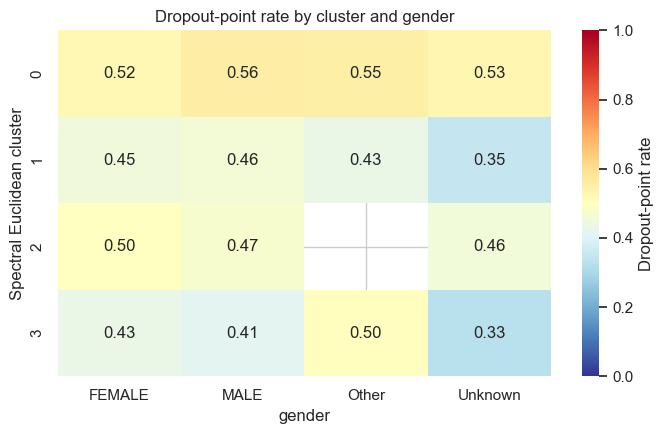

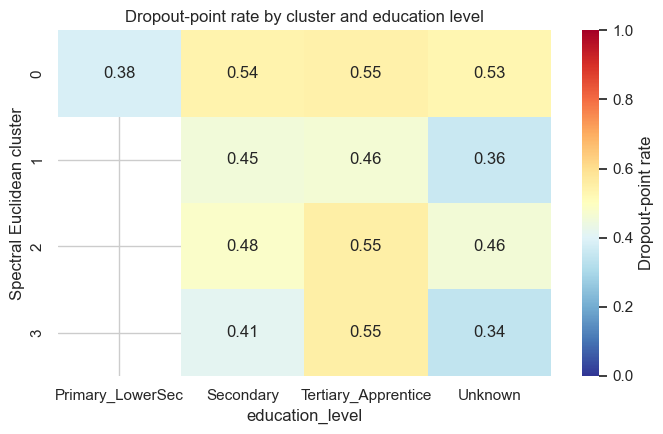

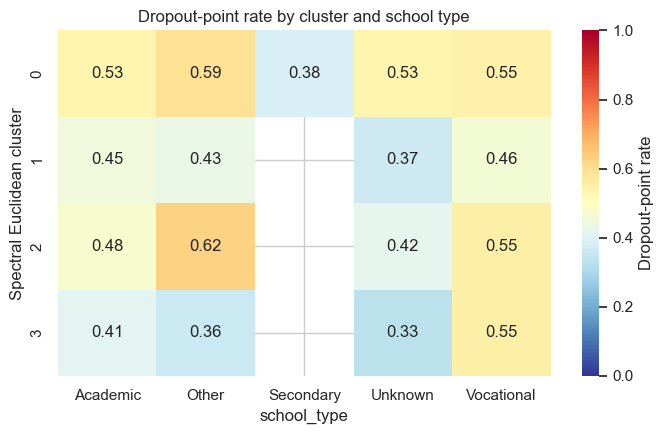

school_type,Academic,Other,Secondary,Unknown,Vocational
cluster_spectral_eucl,,,,,
0,0.533821,0.591743,0.382979,0.533451,0.546479
1,0.450565,0.433333,NaN,0.366071,0.462366
2,0.476190,0.625000,NaN,0.419355,0.551020
3,0.412670,0.360000,NaN,0.328859,0.554140


In [10]:
def outcome_by_cluster_and_group(df, group_col, min_n=MIN_GROUP_SIZE, cluster_col=CLUSTER_COL, outcome_col=OUTCOME_COL):
    table = (
        df.groupby([cluster_col, group_col], observed=False)
        .agg(
            n_rows=("user_id", "size"),
            n_unique_users=("user_id", "nunique"),
            dropout_point_rate=(outcome_col, "mean"),
        )
        .reset_index()
    )
    table = table[table["n_rows"] >= min_n].copy()

    cluster_rates = df.groupby(cluster_col, observed=False)[outcome_col].mean().rename("cluster_rate")
    table = table.merge(cluster_rates, on=cluster_col, how="left")
    table["rate_gap_vs_cluster"] = table["dropout_point_rate"] - table["cluster_rate"]
    table["disparity_ratio_vs_cluster"] = table["dropout_point_rate"] / table["cluster_rate"].replace(0, np.nan)
    table["support_note"] = np.where(
        table["n_unique_users"] < min_n,
        "low unique-user support",
        "",
    )
    return table


def plot_outcome_heatmap(table, group_col, title):
    pivot = table.pivot(index=CLUSTER_COL, columns=group_col, values="dropout_point_rate")
    plt.figure(figsize=(max(7, 1.1 * len(pivot.columns)), 4.5))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlBu_r", vmin=0, vmax=1, cbar_kws={"label": "Dropout-point rate"})
    plt.title(title)
    plt.xlabel(group_col)
    plt.ylabel("Spectral Euclidean cluster")
    plt.tight_layout()
    plt.show()
    return pivot


gender_outcome = outcome_by_cluster_and_group(analysis_df, "gender")
education_outcome = outcome_by_cluster_and_group(analysis_df, "education_level")
school_outcome = outcome_by_cluster_and_group(analysis_df, "school_type")

plot_outcome_heatmap(gender_outcome, "gender", "Dropout-point rate by cluster and gender")
plot_outcome_heatmap(education_outcome, "education_level", "Dropout-point rate by cluster and education level")
plot_outcome_heatmap(school_outcome, "school_type", "Dropout-point rate by cluster and school type")

In [11]:
fairness_flags = pd.concat(
    [
        gender_outcome.assign(attribute="gender", group=gender_outcome["gender"]),
        education_outcome.assign(attribute="education_level", group=education_outcome["education_level"]),
        school_outcome.assign(attribute="school_type", group=school_outcome["school_type"]),
    ],
    ignore_index=True,
)

fairness_flags = fairness_flags[
    (fairness_flags["disparity_ratio_vs_cluster"] < DISPARITY_LOW)
    | (fairness_flags["disparity_ratio_vs_cluster"] > DISPARITY_HIGH)
].copy()

fairness_flags["interpretation_note"] = np.select(
    [
        fairness_flags["group"].astype(str).str.lower().eq("unknown"),
        fairness_flags["support_note"].ne(""),
    ],
    [
        "Unknown category: interpret mainly as missingness / data-quality signal",
        "Small unique-user support: interpret cautiously",
    ],
    default="",
)

fairness_flags = fairness_flags[[
    CLUSTER_COL,
    "attribute",
    "group",
    "n_rows",
    "n_unique_users",
    "dropout_point_rate",
    "cluster_rate",
    "rate_gap_vs_cluster",
    "disparity_ratio_vs_cluster",
    "interpretation_note",
]].sort_values("disparity_ratio_vs_cluster")

fairness_flags.round(3)

,cluster_spectral_eucl,attribute,group,n_rows,n_unique_users,dropout_point_rate,cluster_rate,rate_gap_vs_cluster,disparity_ratio_vs_cluster,interpretation_note
15,0,education_level,Primary_LowerSec,47,28,0.383,0.536,-0.153,0.714,Small unique-user support: interpret cautiously
30,0,school_type,Secondary,47,28,0.383,0.536,-0.153,0.714,Small unique-user support: interpret cautiously
14,3,gender,Unknown,138,111,0.326,0.417,-0.091,0.782,Unknown category: interpret mainly as missingn...
7,1,gender,Unknown,103,82,0.350,0.443,-0.094,0.788,Unknown category: interpret mainly as missingn...
43,3,school_type,Unknown,149,121,0.329,0.417,-0.088,0.788,Unknown category: interpret mainly as missingn...
38,2,school_type,Other,32,32,0.625,0.486,0.139,1.286,
26,3,education_level,Tertiary_Apprentice,157,127,0.554,0.417,0.137,1.328,
44,3,school_type,Vocational,157,127,0.554,0.417,0.137,1.328,


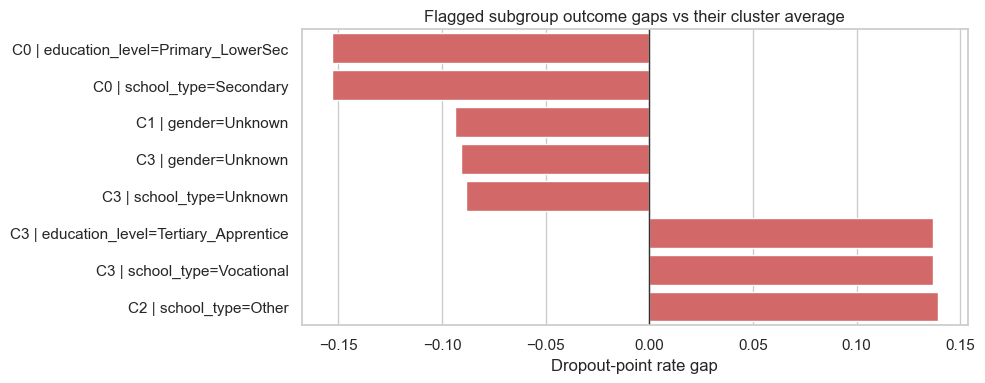

In [12]:
plot_df = fairness_flags.copy()
if plot_df.empty:
    print(f"No subgroup passed the {DISPARITY_LOW} / {DISPARITY_HIGH} disparity-ratio flag with MIN_GROUP_SIZE={MIN_GROUP_SIZE}.")
else:
    plot_df["label"] = (
        "C" + plot_df[CLUSTER_COL].astype(str)
        + " | " + plot_df["attribute"]
        + "=" + plot_df["group"].astype(str)
    )
    plot_df = plot_df.sort_values("rate_gap_vs_cluster")

    plt.figure(figsize=(10, max(4, 0.35 * len(plot_df))))
    sns.barplot(data=plot_df, y="label", x="rate_gap_vs_cluster", color="#E45756")
    plt.axvline(0, color="#333333", linewidth=1)
    plt.title("Flagged subgroup outcome gaps vs their cluster average")
    plt.xlabel("Dropout-point rate gap")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

## 7. Intersectional Checks

Look at higher-risk combinations without repeating every possible table. Small groups are filtered out. The counts again distinguish trajectory rows from unique users.

In [13]:
def intersectional_outcome(df, group_cols, min_n=MIN_GROUP_SIZE, outcome_col=OUTCOME_COL):
    table = (
        df.groupby(group_cols, observed=False)
        .agg(
            n_rows=("user_id", "size"),
            n_unique_users=("user_id", "nunique"),
            dropout_point_rate=(outcome_col, "mean"),
        )
        .reset_index()
    )
    return table[table["n_rows"] >= min_n].sort_values("dropout_point_rate", ascending=False)


gender_education = intersectional_outcome(analysis_df, ["gender", "education_level"])
cluster_gender = intersectional_outcome(analysis_df, [CLUSTER_COL, "gender"])
cluster_education = intersectional_outcome(analysis_df, [CLUSTER_COL, "education_level"])

display(gender_education.head(10))
display(cluster_gender.head(10))
display(cluster_education.head(10))

,gender,education_level,n_rows,n_unique_users,dropout_point_rate
6,MALE,Tertiary_Apprentice,154,89,0.545455
2,FEMALE,Tertiary_Apprentice,475,293,0.526316
8,Other,Secondary,231,137,0.510823
5,MALE,Secondary,2243,1290,0.508248
1,FEMALE,Secondary,3171,1885,0.490382
7,MALE,Unknown,100,61,0.490000
3,FEMALE,Unknown,189,122,0.470899
11,Unknown,Unknown,828,436,0.468599
0,FEMALE,Primary_LowerSec,41,19,0.341463


,cluster_spectral_eucl,gender,n_rows,n_unique_users,dropout_point_rate
1,0,MALE,1504,979,0.558511
2,0,Other,157,113,0.554140
3,0,Unknown,530,331,0.530189
0,0,FEMALE,2279,1558,0.521281
14,3,Other,52,43,0.500000
8,2,FEMALE,321,312,0.498442
9,2,MALE,203,198,0.472906
5,1,MALE,315,278,0.460317
11,2,Unknown,57,55,0.456140
4,1,FEMALE,499,447,0.452906


,cluster_spectral_eucl,education_level,n_rows,n_unique_users,dropout_point_rate
14,3,Tertiary_Apprentice,157,127,0.554140
10,2,Tertiary_Apprentice,49,48,0.551020
2,0,Tertiary_Apprentice,355,248,0.546479
1,0,Secondary,3350,2239,0.538806
3,0,Unknown,718,466,0.527855
9,2,Secondary,467,453,0.481799
6,1,Tertiary_Apprentice,93,81,0.462366
11,2,Unknown,89,86,0.460674
5,1,Secondary,715,640,0.454545
13,3,Secondary,1113,905,0.411500


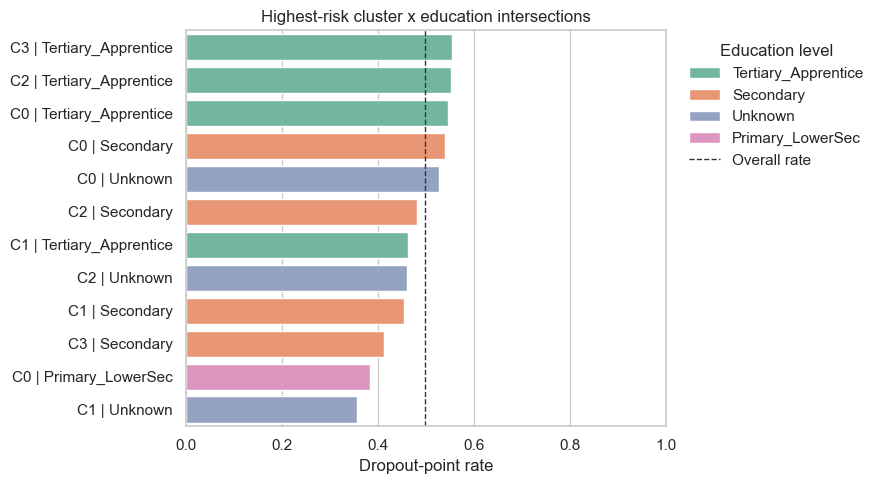

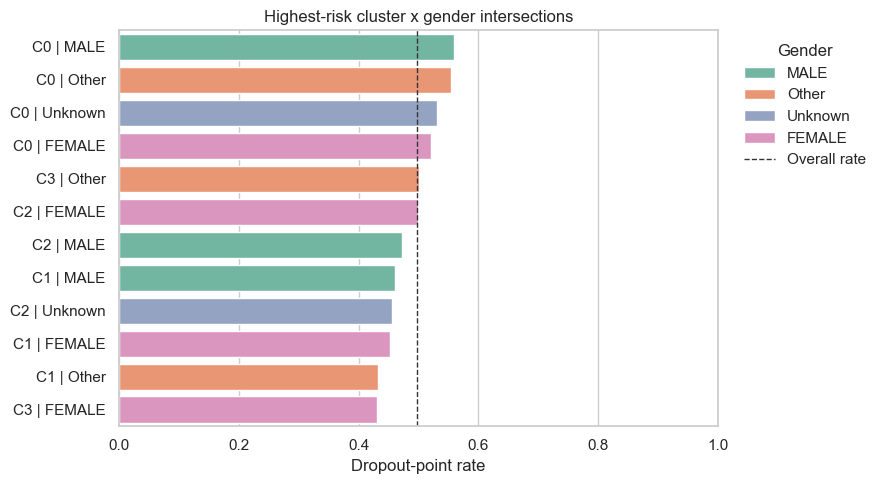

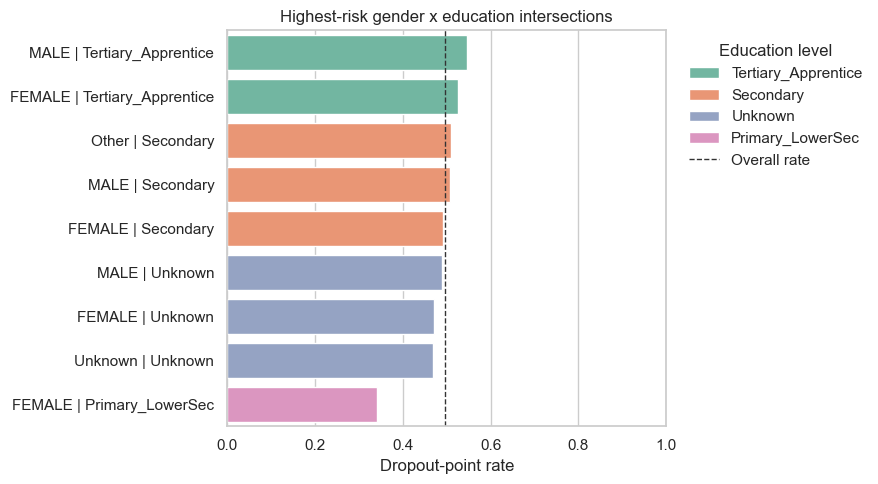

In [14]:
def plot_top_intersections(table, label_cols, hue_col, title, legend_title, top_n=12):
    plot_df = table.head(top_n).copy()
    plot_df["label"] = plot_df[label_cols].astype(str).agg(" | ".join, axis=1)

    plt.figure(figsize=(9, 5))
    sns.barplot(
        data=plot_df,
        y="label",
        x="dropout_point_rate",
        hue=hue_col,
        dodge=False,
    )
    plt.axvline(
        analysis_df[OUTCOME_COL].mean(),
        color="#333333",
        linestyle="--",
        linewidth=1,
        label="Overall rate",
    )
    plt.title(title)
    plt.xlabel("Dropout-point rate")
    plt.ylabel("")
    plt.xlim(0, 1)
    plt.legend(title=legend_title, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


cluster_education_plot = cluster_education.copy()
cluster_education_plot[CLUSTER_COL] = "C" + cluster_education_plot[CLUSTER_COL].astype(str)
plot_top_intersections(
    cluster_education_plot,
    [CLUSTER_COL, "education_level"],
    "education_level",
    "Highest-risk cluster x education intersections",
    "Education level",
)

cluster_gender_plot = cluster_gender.copy()
cluster_gender_plot[CLUSTER_COL] = "C" + cluster_gender_plot[CLUSTER_COL].astype(str)
plot_top_intersections(
    cluster_gender_plot,
    [CLUSTER_COL, "gender"],
    "gender",
    "Highest-risk cluster x gender intersections",
    "Gender",
)

plot_top_intersections(
    gender_education,
    ["gender", "education_level"],
    "education_level",
    "Highest-risk gender x education intersections",
    "Education level",
)

## 8. Engagement and Cluster Diversity

Check whether clusters differ in engagement and whether similar engagement levels have different outcomes by gender.

,count,mean,std,cv
cluster_spectral_eucl,,,,
0,4470,0.045,0.042,0.929
1,954,0.062,0.060,0.979
2,607,0.063,0.058,0.913
3,1467,0.058,0.056,0.970


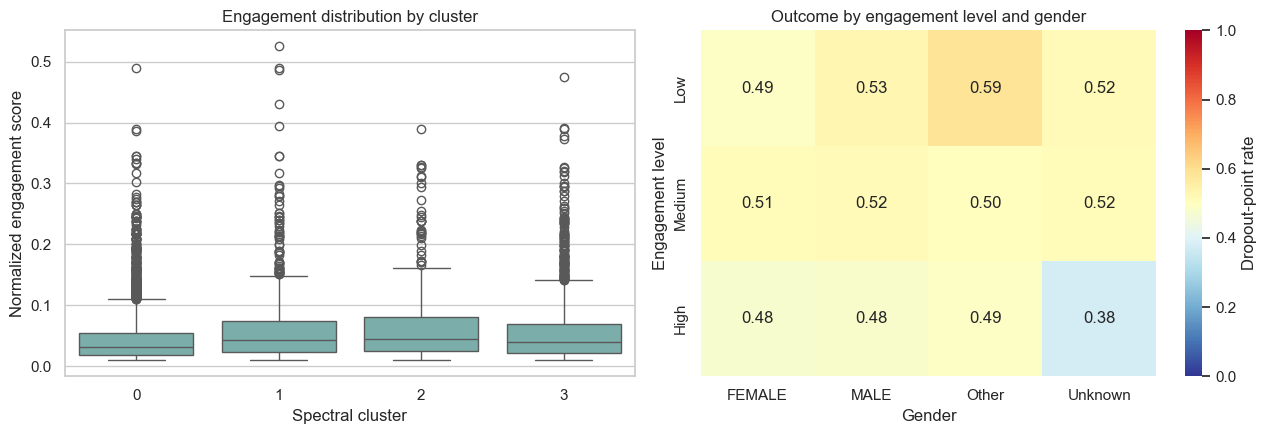

In [15]:
engagement_candidates = [
    "total_events_0_2",
    "n_active_days_0_2",
    "n_sessions_0_2",
    "n_click_events_0_2",
    "n_view_events_0_2",
]
engagement_cols = [c for c in engagement_candidates if c in df_stage1.columns]

if engagement_cols:
    engagement = df_stage1[["user_id"] + engagement_cols].copy()
    for col in engagement_cols:
        engagement[col] = pd.to_numeric(engagement[col], errors="coerce").fillna(0)
        max_val = engagement[col].max()
        engagement[col + "_norm"] = engagement[col] / max_val if max_val > 0 else 0

    norm_cols = [c + "_norm" for c in engagement_cols]
    engagement["engagement_score"] = engagement[norm_cols].mean(axis=1)

    analysis_df = analysis_df.merge(engagement[["user_id", "engagement_score"]], on="user_id", how="left")
    analysis_df["engagement_level"] = pd.qcut(
        analysis_df["engagement_score"],
        q=3,
        labels=["Low", "Medium", "High"],
        duplicates="drop",
    )

    engagement_by_cluster = analysis_df.groupby(CLUSTER_COL, observed=False)["engagement_score"].agg(["count", "mean", "std"])
    engagement_by_cluster["cv"] = engagement_by_cluster["std"] / engagement_by_cluster["mean"].replace(0, np.nan)
    display(engagement_by_cluster.round(3))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    sns.boxplot(data=analysis_df, x=CLUSTER_COL, y="engagement_score", ax=axes[0], color="#72B7B2")
    axes[0].set_title("Engagement distribution by cluster")
    axes[0].set_xlabel("Spectral cluster")
    axes[0].set_ylabel("Normalized engagement score")

    engage_gender = pd.crosstab(
        analysis_df["engagement_level"],
        analysis_df["gender"],
        values=analysis_df[OUTCOME_COL],
        aggfunc="mean",
    )
    sns.heatmap(engage_gender, annot=True, fmt=".2f", cmap="RdYlBu_r", vmin=0, vmax=1, ax=axes[1], cbar_kws={"label": "Dropout-point rate"})
    axes[1].set_title("Outcome by engagement level and gender")
    axes[1].set_xlabel("Gender")
    axes[1].set_ylabel("Engagement level")

    plt.tight_layout()
    plt.show()
else:
    print("No engagement columns found.")

## 9. Statistical Tests

Test whether cluster assignment is independent from demographic attributes. The p-value answers whether an association is detectable; Cramer's V adds the effect size, which is often more useful for interpretation with large samples.

In [16]:
def chi_square_stat_from_crosstab(table):
    observed = table.to_numpy(dtype=float)
    total = observed.sum()
    if total == 0:
        return np.nan
    row_totals = observed.sum(axis=1, keepdims=True)
    col_totals = observed.sum(axis=0, keepdims=True)
    expected = row_totals @ col_totals / total
    with np.errstate(divide="ignore", invalid="ignore"):
        chi_terms = np.where(expected > 0, (observed - expected) ** 2 / expected, 0)
    return float(np.nansum(chi_terms))


def cramers_v_from_crosstab(table, chi2=None):
    if chi2 is None or np.isnan(chi2):
        chi2 = chi_square_stat_from_crosstab(table)
    n = table.to_numpy().sum()
    min_dim = min(table.shape) - 1
    if n == 0 or min_dim <= 0 or np.isnan(chi2):
        return np.nan
    return np.sqrt(chi2 / (n * min_dim))


def chi_square_test(df, cluster_col, attr):
    table = pd.crosstab(df[cluster_col], df[attr])
    dof = (table.shape[0] - 1) * (table.shape[1] - 1)

    if chi2_contingency is not None:
        chi2, p_value, dof, expected = chi2_contingency(table)
        note = ""
    else:
        chi2 = chi_square_stat_from_crosstab(table)
        p_value = np.nan
        note = "scipy not available; p-value not computed"

    return {
        "attribute": attr,
        "chi2": chi2,
        "p_value": p_value,
        "dof": dof,
        "cramers_v": cramers_v_from_crosstab(table, chi2),
        "significant_at_0_05": bool(p_value < 0.05) if not pd.isna(p_value) else False,
        "note": note,
    }

attributes = ["gender", "education_level", "school_type", "canton"]
chi_square_results = pd.DataFrame([
    chi_square_test(analysis_df, CLUSTER_COL, attr)
    for attr in attributes
    if attr in analysis_df.columns
]).sort_values("cramers_v", ascending=False, na_position="last")

chi_square_results.round(4)

,attribute,chi2,p_value,dof,cramers_v,significant_at_0_05,note
3,canton,480.1207,0.0000,48,0.1461,True,
2,school_type,37.8775,0.0002,12,0.0410,True,
1,education_level,27.2046,0.0013,9,0.0348,True,
0,gender,10.1982,0.3347,9,0.0213,False,


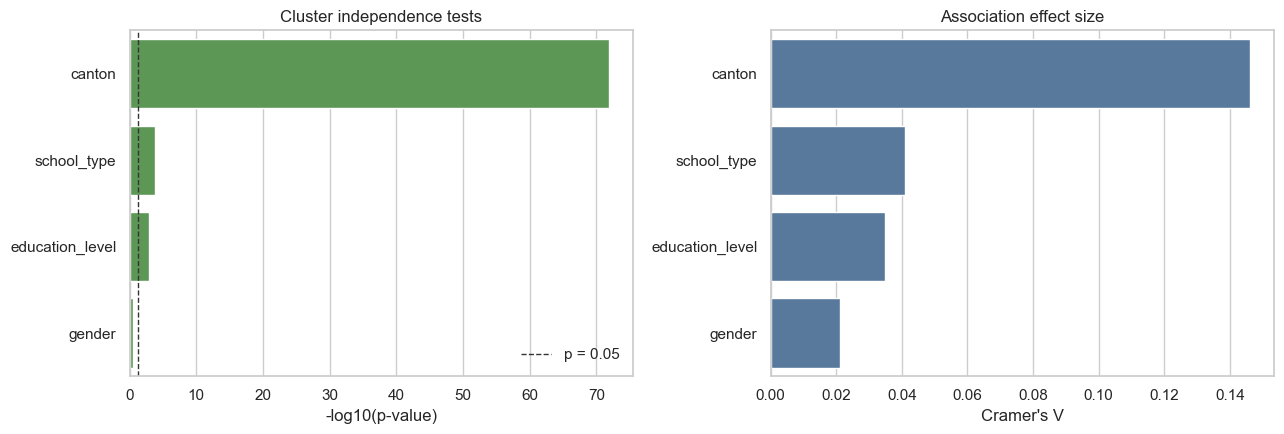

In [17]:
plot_tests = chi_square_results.copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

plot_p = plot_tests.dropna(subset=["p_value"]).copy()
if plot_p.empty:
    axes[0].axis("off")
    axes[0].set_title("p-values unavailable")
else:
    plot_p["minus_log10_p"] = -np.log10(plot_p["p_value"].clip(lower=1e-300))
    sns.barplot(data=plot_p, x="minus_log10_p", y="attribute", color="#54A24B", ax=axes[0])
    axes[0].axvline(-np.log10(0.05), color="#333333", linestyle="--", linewidth=1, label="p = 0.05")
    axes[0].set_title("Cluster independence tests")
    axes[0].set_xlabel("-log10(p-value)")
    axes[0].set_ylabel("")
    axes[0].legend()

plot_v = plot_tests.dropna(subset=["cramers_v"]).copy()
if plot_v.empty:
    axes[1].axis("off")
    axes[1].set_title("Effect sizes unavailable")
else:
    sns.barplot(data=plot_v, x="cramers_v", y="attribute", color="#4C78A8", ax=axes[1])
    axes[1].set_title("Association effect size")
    axes[1].set_xlabel("Cramer's V")
    axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## 10. Robustness Across Clustering Methods

Repeat the key fairness diagnostics for the matched K-Means alternatives exported by `clustering_spectral.ipynb`. This does not combine cluster labels; it checks whether the same demographic associations appear under plausible alternative partitions.

In [18]:
def method_cluster_summary(df, cluster_col, outcome_col=OUTCOME_COL):
    summary = (
        df.groupby(cluster_col, observed=False)
        .agg(
            n_rows=("user_id", "size"),
            n_unique_users=("user_id", "nunique"),
            dropout_point_rate=(outcome_col, "mean"),
        )
        .reset_index()
        .rename(columns={cluster_col: "cluster_label"})
    )
    summary.insert(0, "method", cluster_col)
    return summary


def method_chi_square_summary(df, cluster_cols, attrs):
    rows = []
    for method in cluster_cols:
        if method not in df.columns:
            continue
        for attr in attrs:
            if attr not in df.columns:
                continue
            result = chi_square_test(df, method, attr)
            result["method"] = method
            rows.append(result)
    return pd.DataFrame(rows)


available_robustness_cols = [c for c in ROBUSTNESS_CLUSTER_COLS if c in analysis_df.columns]
robustness_cluster_summaries = pd.concat(
    [method_cluster_summary(analysis_df, CLUSTER_COL)]
    + [method_cluster_summary(analysis_df, col) for col in available_robustness_cols],
    ignore_index=True,
)

robustness_chi_square = method_chi_square_summary(
    analysis_df,
    [CLUSTER_COL] + available_robustness_cols,
    ["gender", "education_level", "school_type", "canton"],
)

robustness_chi_square = robustness_chi_square[[
    "method", "attribute", "chi2", "p_value", "dof", "cramers_v", "significant_at_0_05", "note"
]].sort_values(["attribute", "cramers_v"], ascending=[True, False])

display(robustness_cluster_summaries.round(3))
display(robustness_chi_square.round(4))

,method,cluster_label,n_rows,n_unique_users,dropout_point_rate
0,cluster_spectral_eucl,0,4470,2981,0.536
1,cluster_spectral_eucl,1,954,841,0.443
2,cluster_spectral_eucl,2,607,589,0.486
3,cluster_spectral_eucl,3,1467,1197,0.417
4,kmeans_eucl,0,4253,2840,0.538
5,kmeans_eucl,1,1213,953,0.378
6,kmeans_eucl,2,591,571,0.492
7,kmeans_eucl,3,1441,1152,0.477
8,kmeans_flat,0,522,505,0.454
9,kmeans_flat,1,5881,3678,0.525


,method,attribute,chi2,p_value,dof,cramers_v,significant_at_0_05,note
11,kmeans_flat,canton,1279.5870,0.0000,48,0.2385,True,
7,kmeans_eucl,canton,753.3250,0.0000,48,0.1830,True,
3,cluster_spectral_eucl,canton,480.1207,0.0000,48,0.1461,True,
5,kmeans_eucl,education_level,43.2083,0.0000,9,0.0438,True,
1,cluster_spectral_eucl,education_level,27.2046,0.0013,9,0.0348,True,
9,kmeans_flat,education_level,12.0012,0.2132,9,0.0231,False,
0,cluster_spectral_eucl,gender,10.1982,0.3347,9,0.0213,False,
4,kmeans_eucl,gender,9.4861,0.3937,9,0.0205,False,
8,kmeans_flat,gender,4.0085,0.9109,9,0.0133,False,
6,kmeans_eucl,school_type,56.7348,0.0000,12,0.0502,True,


## 11. Export Clean Fairness Tables

In [19]:
analysis_df.to_csv(OUTPUT_DIR / "ethical_analysis_clean.csv", index=False)
cluster_summary.to_csv(OUTPUT_DIR / "fairness_cluster_summary.csv")
gender_outcome.to_csv(OUTPUT_DIR / "fairness_outcome_by_cluster_gender.csv", index=False)
education_outcome.to_csv(OUTPUT_DIR / "fairness_outcome_by_cluster_education.csv", index=False)
school_outcome.to_csv(OUTPUT_DIR / "fairness_outcome_by_cluster_school_type.csv", index=False)
fairness_flags.to_csv(OUTPUT_DIR / "fairness_flags.csv", index=False)
chi_square_results.to_csv(OUTPUT_DIR / "fairness_chi_square_tests.csv", index=False)
robustness_cluster_summaries.to_csv(OUTPUT_DIR / "fairness_robustness_cluster_summaries.csv", index=False)
robustness_chi_square.to_csv(OUTPUT_DIR / "fairness_robustness_chi_square_tests.csv", index=False)

print("Saved clean fairness outputs to", OUTPUT_DIR)

Saved clean fairness outputs to outputs
